In [1]:
# Cell 1 - Imports and Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
import nltk
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK data
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

sns.set_theme(style="whitegrid")

df = pd.read_csv('../data/Reviews_clean.csv')
print(f"Data loaded: {df.shape}")
print("Ready for Sentiment Analysis!")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\tanus\AppData\Roaming\nltk_data...
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tanus\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\tanus\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\tanus\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


Data loaded: (393914, 13)
Ready for Sentiment Analysis!


In [2]:
# Cell 2 - VADER Sentiment Scoring
sia = SentimentIntensityAnalyzer()

# Sample 50,000 rows for speed
df_sample = df.sample(50000, random_state=42).copy()

# Apply VADER to review text
print("Running sentiment analysis... (takes ~30 seconds)")
df_sample['sentiment_scores'] = df_sample['Text'].apply(
    lambda x: sia.polarity_scores(str(x))
)
df_sample['compound'] = df_sample['sentiment_scores'].apply(lambda x: x['compound'])
df_sample['sentiment'] = df_sample['compound'].apply(
    lambda x: 'Positive' if x >= 0.05 else ('Negative' if x <= -0.05 else 'Neutral')
)

print("\nSentiment Distribution:")
print(df_sample['sentiment'].value_counts())
print(f"\nAverage compound score: {df_sample['compound'].mean():.3f}")

Running sentiment analysis... (takes ~30 seconds)

Sentiment Distribution:
sentiment
Positive    43691
Negative     5211
Neutral      1098
Name: count, dtype: int64

Average compound score: 0.647


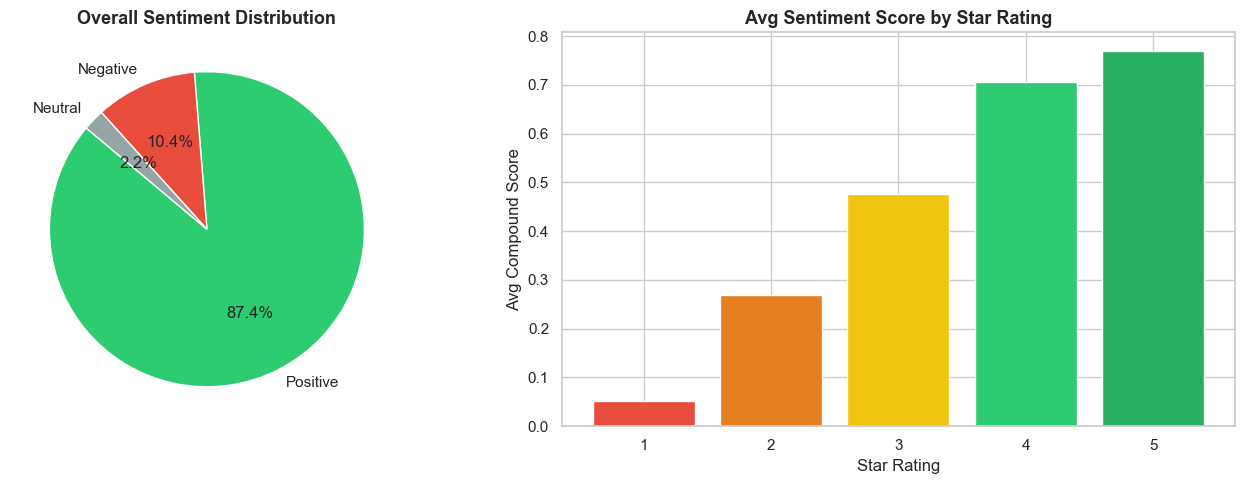

Chart saved!


In [3]:
# Cell 3 - Sentiment vs Star Rating
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sentiment distribution pie
sentiment_counts = df_sample['sentiment'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#95a5a6']
axes[0].pie(sentiment_counts.values, labels=sentiment_counts.index,
            colors=colors, autopct='%1.1f%%', startangle=140)
axes[0].set_title('Overall Sentiment Distribution', fontsize=13, fontweight='bold')

# Average compound score by star rating
avg_compound = df_sample.groupby('Score')['compound'].mean()
axes[1].bar(avg_compound.index, avg_compound.values,
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'])
axes[1].set_title('Avg Sentiment Score by Star Rating', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Avg Compound Score')

plt.tight_layout()
plt.savefig('../images/sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

Generating word clouds... (takes ~20 seconds)


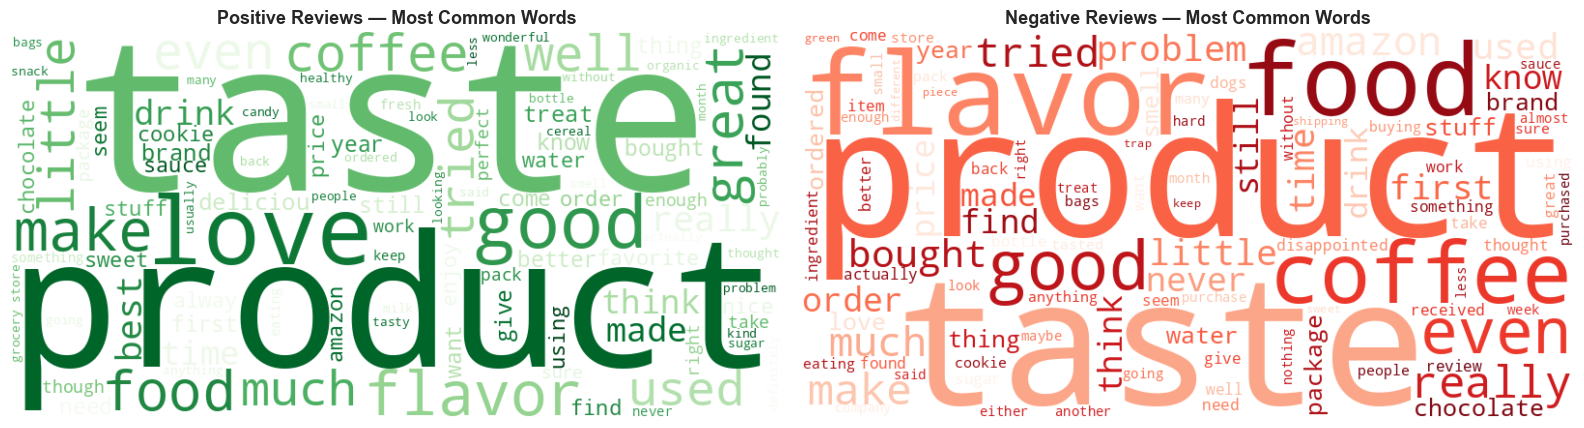

Word clouds saved!


In [4]:
# Cell 4 - Word Clouds for Positive and Negative Reviews
stop_words = set(stopwords.words('english'))

def get_words(sentiment_label):
    texts = df_sample[df_sample['sentiment'] == sentiment_label]['Text'].str.cat(sep=' ')
    tokens = word_tokenize(texts.lower())
    words = [w for w in tokens if w.isalpha() and w not in stop_words and len(w) > 3]
    return ' '.join(words)

print("Generating word clouds... (takes ~20 seconds)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive word cloud
pos_words = get_words('Positive')
wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', max_words=100).generate(pos_words)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Reviews — Most Common Words', fontsize=13, fontweight='bold')

# Negative word cloud
neg_words = get_words('Negative')
wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds', max_words=100).generate(neg_words)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Reviews — Most Common Words', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("Word clouds saved!")

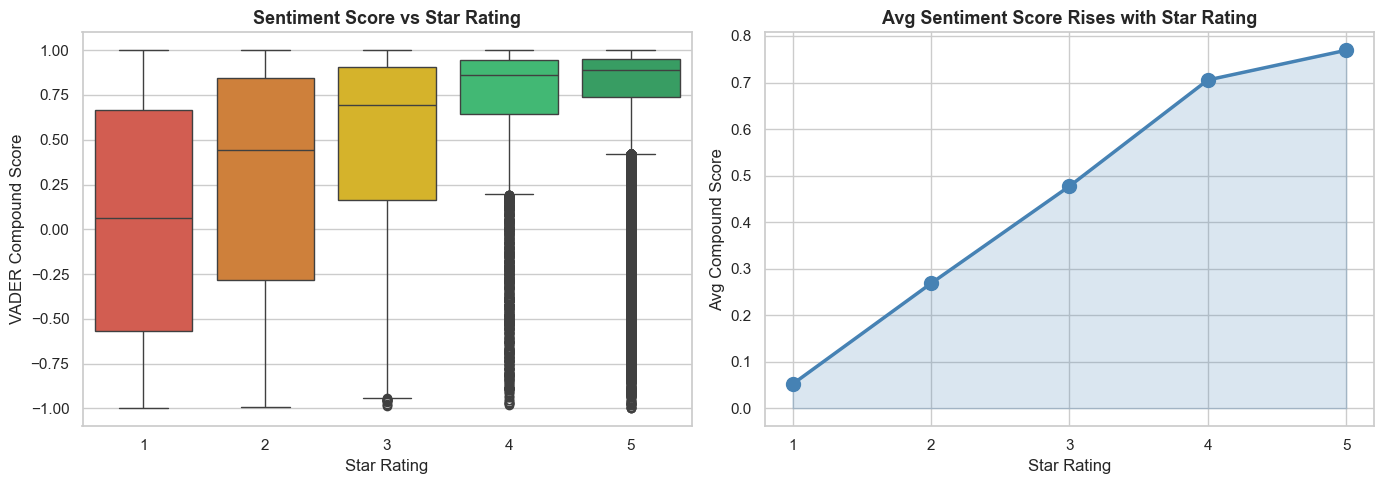

Hero chart saved!


In [5]:
# Cell 5 - Hero Result: Sentiment Score vs Star Rating
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot - compound score by star rating
sns.boxplot(data=df_sample, x='Score', y='compound', ax=axes[0],
            palette=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'])
axes[0].set_title('Sentiment Score vs Star Rating', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('VADER Compound Score')

# Correlation - avg sentiment per score
corr_data = df_sample.groupby('Score')['compound'].mean().reset_index()
axes[1].plot(corr_data['Score'], corr_data['compound'], 
             marker='o', linewidth=2.5, color='steelblue', markersize=10)
axes[1].fill_between(corr_data['Score'], corr_data['compound'], alpha=0.2, color='steelblue')
axes[1].set_title('Avg Sentiment Score Rises with Star Rating', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Avg Compound Score')
axes[1].set_xticks([1,2,3,4,5])

plt.tight_layout()
plt.savefig('../images/sentiment_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print("Hero chart saved!")

In [6]:
# Cell 6 - Sentiment Analysis Summary
correlation = df_sample[['Score', 'compound']].corr().iloc[0,1]

print("=" * 50)
print("   SENTIMENT ANALYSIS COMPLETE — KEY FINDINGS")
print("=" * 50)
print(f"  Reviews analyzed       : 50,000 (sample)")
print(f"  Positive reviews       : {(df_sample['sentiment']=='Positive').sum():,} ({(df_sample['sentiment']=='Positive').mean()*100:.1f}%)")
print(f"  Negative reviews       : {(df_sample['sentiment']=='Negative').sum():,} ({(df_sample['sentiment']=='Negative').mean()*100:.1f}%)")
print(f"  Neutral reviews        : {(df_sample['sentiment']=='Neutral').sum():,} ({(df_sample['sentiment']=='Neutral').mean()*100:.1f}%)")
print(f"  Avg compound score     : {df_sample['compound'].mean():.3f}")
print(f"  Correlation (score↔sentiment): {correlation:.3f}")
print(f"  Top positive words     : taste, love, product, good")
print(f"  Top negative words     : flavor, product, taste, food")
print("=" * 50)

   SENTIMENT ANALYSIS COMPLETE — KEY FINDINGS
  Reviews analyzed       : 50,000 (sample)
  Positive reviews       : 43,691 (87.4%)
  Negative reviews       : 5,211 (10.4%)
  Neutral reviews        : 1,098 (2.2%)
  Avg compound score     : 0.647
  Correlation (score↔sentiment): 0.480
  Top positive words     : taste, love, product, good
  Top negative words     : flavor, product, taste, food
